# Экспериментальный пайплайн для логистической регрессии

Этот ноутбук запускает  экспериментальный цикл для уже подготовленных файлов с признаками.

Контракт:
- входной CSV содержит числовые признаки, готовые для подачи в модель;
- целевая переменная может лежать в том же CSV или в отдельном CSV с таргетом;
- в признаках нет пропусков;
- валидация использует `StratifiedKFold`, чтобы сохранять баланс классов в каждом фолде;

In [1]:
from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('C:/Users/stoli/PycharmProjects/Credit_score')

## Конфигурация

Укажи в `FEATURES_PATH` путь к CSV с подготовленными признаками. Если таргет лежит в отдельном файле, укажи `TARGET_PATH`; иначе используй `TARGET_PATH = None`.

In [2]:
FEATURES_PATH = PROJECT_ROOT / "data" / "X_train_prepared.csv"
TARGET_PATH: Path | None = PROJECT_ROOT / "data" / "y_train.csv"
TARGET = "Credit_Score"
INDEX_COLUMN = "source_index"

N_SPLITS = 5
RANDOM_STATE = 42
MAX_ITER = 1_000
CLASS_WEIGHT = "balanced"  # используй None, чтобы отключить веса классов
SCALE_FEATURES = True

# Технические колонки, которые есть в файле, но не должны участвовать в обучении.
DROP_COLUMNS: list[str] = [INDEX_COLUMN]

# Для текущей кодировки: 0 = Poor, 1 = Standard, 2 = Good.
# Если таргет строковый, можно указать ["Standard", "Good"].
PRIORITY_CLASSES = [1, 2]
DEFAULT_MIN_RECALL = 0.50
MIN_RECALL_BY_CLASS = {
    1: 0.50,  # Standard
    2: 0.50,  # Good
}

## Загрузка и проверка готовых признаков

In [3]:
def load_ready_features(
    features_path: str | Path,
    target: str,
    target_path: str | Path | None = None,
    index_column: str | None = None,
) -> tuple[pd.DataFrame, pd.Series]:
    features = pd.read_csv(features_path)

    if target_path is None:
        if target not in features.columns:
            raise ValueError(f"Target column '{target}' was not found in {features_path}.")
        y = features[target]
        X = features.drop(columns=[target])
        return X, y

    target_data = pd.read_csv(target_path)
    if target not in target_data.columns:
        raise ValueError(f"Target column '{target}' was not found in {target_path}.")

    if index_column and index_column in features.columns and index_column in target_data.columns:
        data = features.merge(
            target_data[[index_column, target]],
            on=index_column,
            how="inner",
            validate="one_to_one",
        )
        if len(data) != len(features):
            raise ValueError("Feature and target files do not match by index column.")
        y = data[target]
        X = data.drop(columns=[target])
        return X, y

    if len(features) != len(target_data):
        raise ValueError("Feature and target files have different row counts and cannot be aligned.")
    return features, target_data[target]


def validate_ready_features(X: pd.DataFrame, y: pd.Series, n_splits: int) -> None:
    if X.empty:
        raise ValueError("Feature matrix is empty.")
    if y.empty:
        raise ValueError("Target vector is empty.")
    if y.isna().any():
        raise ValueError("Target contains missing values.")

    missing_by_column = X.isna().sum()
    missing_by_column = missing_by_column[missing_by_column > 0]
    if not missing_by_column.empty:
        details = missing_by_column.sort_values(ascending=False).head(20).to_dict()
        raise ValueError(f"Ready features must not contain missing values: {details}")

    non_numeric = [
        column
        for column in X.columns
        if not pd.api.types.is_numeric_dtype(X[column])
    ]
    if non_numeric:
        preview = ", ".join(non_numeric[:20])
        raise ValueError(f"Ready features must be numeric. Non-numeric columns: {preview}")

    class_counts = y.value_counts()
    if class_counts.size < 2:
        raise ValueError("Target must contain at least two classes.")

    too_small = class_counts[class_counts < n_splits]
    if not too_small.empty:
        raise ValueError(
            "Each class must have at least n_splits rows for StratifiedKFold. "
            f"Too small classes: {too_small.to_dict()}"
        )

In [4]:
X, y = load_ready_features(FEATURES_PATH, TARGET, TARGET_PATH, INDEX_COLUMN)

if DROP_COLUMNS:
    present_drop_columns = [column for column in DROP_COLUMNS if column in X.columns]
    if present_drop_columns:
        X = X.drop(columns=present_drop_columns)

validate_ready_features(X, y, N_SPLITS)

display(pd.DataFrame({"rows": [len(X)], "features": [X.shape[1]], "classes": [y.nunique()]}))
display(y.value_counts().rename_axis(TARGET).to_frame("rows"))
X.head()

,rows,features,classes
0,80000,84,3


,rows
Credit_Score,
1,42539
0,23199
2,14262


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Month_Num,Loan_Type_Count,Loan_Type__Auto Loan,Loan_Type__Credit-Builder Loan,Loan_Type__Debt Consolidation Loan,Loan_Type__Home Equity Loan,Loan_Type__Mortgage Loan,Loan_Type__Not Specified,Loan_Type__Payday Loan,Loan_Type__Personal Loan,Loan_Type__Student Loan,debt_to_annual_income,debt_to_monthly_salary,emi_to_monthly_salary,investment_to_monthly_salary,balance_to_monthly_salary,available_income_after_emi,available_income_after_emi_and_investment,delayed_payment_ratio,avg_delay_per_delayed_payment,inquiries_per_credit_account,credit_cards_per_bank_account,loans_per_bank_account,credit_history_years,credit_age_per_loan,total_credit_products,loan_diversity_ratio,has_negative_payment_history,high_utilization_flag,low_balance_flag,debt_per_credit_product,Month_April,Month_August,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Standard,Credit_Mix_Пропуск,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,-0.030611,-0.611964,-0.642510,0.244190,-0.742425,-0.861474,-0.219725,-0.623109,0.985720,-0.393207,-1.505713,-0.554578,0.859029,-0.329758,-0.237681,-0.503647,-0.303578,-0.218091,-0.219659,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,-0.673161,1.489693,-0.362890,-0.343246,-0.047387,-0.148815,-0.037083,-0.637288,-0.419101,-0.031142,-0.657871,-1.410209,-0.608467,-0.379271,-0.303578,-0.285421,-0.544451,0.004903,0.038434,1.393106,-0.819264,-0.403018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.554897,-0.424391,-0.471108,-0.913945,0.225329,0.396244,-0.628211,0.463582,1.065699,1.253837,0.580222,-0.227752,-1.404240,-0.407375,-0.284630,0.022808,-1.419108,0.218168,-0.628165,1.504208,-0.681172,-0.670319,1.477777,-0.676123,-0.681113,-0.685325,-0.673161,-0.671279,-0.306144,-0.282314,-0.217357,-0.190195,0.102000,-0.459395,-0.239079,0.858543,-0.232986,0.727008,0.856331,-0.095708,-1.419108,-0.561860,-0.281714,0.004903,0.038434,-0.717821,-0.819264,-0.102382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.335468,-1.008337,-0.925790,-0.141855,-0.742425,0.281906,0.188761,-0.079763,0.105948,0.371545,-0.462745,-0.505666,0.822188,-0.580490,-0.266127,-0.530037,0.339611,0.218168,0.188847,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,1.485530,-0.671279,0.109602,-0.064747,-0.180854,-0.146947,0.959943,-0.913249,-0.642017,-0.315013,-0.217514,-0.341600,-0.461987,0.131143,0.339611,-0.284447,-0.281714,0.004903,0.038434,1.393106,-0.819264,-0.466594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.172627,0.420220,0.371161,-0.141855,0.709207,0.624920,-0.628211,0.463582,0.745782,-0.217641,-1.505713,-0.511150,0.985891,-0.226477,-0.227643,0.673016,1.475241,0.218168,-0.628165,-0.664802,-0.681172,-0.670319,-0.676692,-0.676123,-0.68

## Вспомогательные функции для метрик

In [5]:
def build_logreg_pipeline() -> Pipeline:
    steps = []
    if SCALE_FEATURES:
        steps.append(("scaler", StandardScaler()))
    steps.append(
        (
            "model",
            LogisticRegression(
                class_weight=CLASS_WEIGHT,
                max_iter=MAX_ITER,
                random_state=RANDOM_STATE,
            ),
        )
    )
    return Pipeline(steps)


def one_vs_rest_targets(y_true: np.ndarray, classes: Sequence[str]) -> np.ndarray:
    if len(classes) == 2:
        labels = np.arange(len(classes))
        return np.column_stack([(y_true == label).astype(int) for label in labels])
    return label_binarize(y_true, classes=np.arange(len(classes)))


def roc_auc_metric(y_true: np.ndarray, y_score: np.ndarray, classes: Sequence[str], average: str) -> float:
    if len(classes) == 2:
        return float(roc_auc_score(y_true, y_score[:, 1], average=average))
    return float(
        roc_auc_score(
            y_true,
            y_score,
            labels=np.arange(len(classes)),
            multi_class="ovr",
            average=average,
        )
    )


def average_precision_metric(y_true: np.ndarray, y_score: np.ndarray, classes: Sequence[str], average: str) -> float:
    y_binary = one_vs_rest_targets(y_true, classes)
    return float(average_precision_score(y_binary, y_score, average=average))


def compute_fold_metrics(
    fold: int,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    classes: Sequence[str],
) -> dict[str, float]:
    return {
        "fold": fold,
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_metric(y_true, y_score, classes, average="macro"),
        "roc_auc_ovr_weighted": roc_auc_metric(y_true, y_score, classes, average="weighted"),
        "average_precision_macro": average_precision_metric(y_true, y_score, classes, average="macro"),
        "average_precision_weighted": average_precision_metric(y_true, y_score, classes, average="weighted"),
    }

In [6]:
def compute_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    classes: Sequence[str],
) -> pd.DataFrame:
    labels = np.arange(len(classes))
    precision, recall, _, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )
    y_binary = one_vs_rest_targets(y_true, classes)

    rows = []
    for class_idx, class_name in enumerate(classes):
        rows.append(
            {
                "class": class_name,
                "precision": precision[class_idx],
                "recall": recall[class_idx],
                "roc_auc_ovr": roc_auc_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "average_precision": average_precision_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "support": support[class_idx],
            }
        )

    return pd.DataFrame(rows).set_index("class")


def curve_frame(precision: np.ndarray, recall: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    padded_thresholds = np.append(thresholds, np.nan)
    return pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "threshold": padded_thresholds,
        }
    )


def compute_pr_curves(y_true: np.ndarray, y_score: np.ndarray, classes: Sequence[str]) -> dict[str, pd.DataFrame]:
    curves = {}
    y_binary = one_vs_rest_targets(y_true, classes)
    for class_idx, class_name in enumerate(classes):
        precision, recall, thresholds = precision_recall_curve(
            y_binary[:, class_idx],
            y_score[:, class_idx],
        )
        curves[class_name] = curve_frame(precision, recall, thresholds)
    return curves


def class_label_to_index(class_label: object, label_encoder: LabelEncoder) -> int:
    for class_idx, original_label in enumerate(label_encoder.classes_):
        if class_label == original_label or str(class_label) == str(original_label):
            return class_idx
    known_labels = [str(label) for label in label_encoder.classes_]
    raise ValueError(f"Класс {class_label!r} не найден в таргете. Доступные классы: {known_labels}")


def min_recall_for_class(class_label: object) -> float:
    if class_label in MIN_RECALL_BY_CLASS:
        return MIN_RECALL_BY_CLASS[class_label]
    if str(class_label) in MIN_RECALL_BY_CLASS:
        return MIN_RECALL_BY_CLASS[str(class_label)]
    return DEFAULT_MIN_RECALL


def select_threshold_for_precision(
    y_true_binary: np.ndarray,
    y_score_class: np.ndarray,
    min_recall: float,
) -> dict[str, float | bool]:
    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score_class)
    candidates = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precision[:-1],
            "recall": recall[:-1],
        }
    )
    feasible_candidates = candidates[candidates["recall"] >= min_recall]
    is_feasible = not feasible_candidates.empty

    if is_feasible:
        candidates_for_selection = feasible_candidates
    else:
        candidates_for_selection = candidates

    best = candidates_for_selection.sort_values(
        by=["precision", "threshold", "recall"],
        ascending=[False, False, False],
    ).iloc[0]

    return {
        "threshold": float(best["threshold"]),
        "precision_at_threshold": float(best["precision"]),
        "recall_at_threshold": float(best["recall"]),
        "min_recall": float(min_recall),
        "min_recall_satisfied": bool(is_feasible),
    }


def select_priority_thresholds(
    y_true: np.ndarray,
    y_score: np.ndarray,
    classes: Sequence[str],
    label_encoder: LabelEncoder,
    priority_classes: Sequence[object],
) -> pd.DataFrame:
    y_binary = one_vs_rest_targets(y_true, classes)
    rows = []

    for class_label in priority_classes:
        class_idx = class_label_to_index(class_label, label_encoder)
        row = select_threshold_for_precision(
            y_binary[:, class_idx],
            y_score[:, class_idx],
            min_recall_for_class(class_label),
        )
        row["class"] = str(label_encoder.classes_[class_idx])
        row["class_index"] = class_idx
        rows.append(row)

    return pd.DataFrame(rows).set_index("class_index")


def apply_priority_thresholds(y_score: np.ndarray, thresholds_by_class_index: dict[int, float]) -> np.ndarray:
    adjusted_score = y_score.copy()
    for class_idx, threshold in thresholds_by_class_index.items():
        adjusted_score[:, class_idx] = np.where(
            y_score[:, class_idx] >= threshold,
            y_score[:, class_idx],
            -np.inf,
        )

    adjusted_pred = adjusted_score.argmax(axis=1)
    rows_without_available_class = ~np.isfinite(adjusted_score).any(axis=1)
    if rows_without_available_class.any():
        adjusted_pred[rows_without_available_class] = y_score[rows_without_available_class].argmax(axis=1)
    return adjusted_pred

## Запуск эксперимента со Stratified K-Fold

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
classes = [str(label) for label in label_encoder.classes_]

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
base_pipeline = build_logreg_pipeline()

fold_metrics = []
all_y_true = []
all_y_pred = []
all_y_score = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y_encoded), start=1):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    pipeline = clone(base_pipeline)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_valid)
    y_score = pipeline.predict_proba(X_valid)

    fold_metrics.append(compute_fold_metrics(fold, y_valid, y_pred, y_score, classes))
    all_y_true.append(y_valid)
    all_y_pred.append(y_pred)
    all_y_score.append(y_score)

y_true_oof = np.concatenate(all_y_true)
y_pred_oof = np.concatenate(all_y_pred)
y_score_oof = np.vstack(all_y_score)

fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
summary_metrics_df = pd.DataFrame(
    {
        "mean": fold_metrics_df.mean(numeric_only=True),
        "std": fold_metrics_df.std(numeric_only=True),
    }
)
per_class_metrics_df = compute_per_class_metrics(y_true_oof, y_pred_oof, y_score_oof, classes)
pr_curves = compute_pr_curves(y_true_oof, y_score_oof, classes)

threshold_selection_df = select_priority_thresholds(
    y_true_oof,
    y_score_oof,
    classes,
    label_encoder,
    PRIORITY_CLASSES,
)
thresholds_by_class_index = threshold_selection_df["threshold"].to_dict()
y_pred_thresholded_oof = apply_priority_thresholds(y_score_oof, thresholds_by_class_index)

argmax_oof_metrics = compute_fold_metrics(0, y_true_oof, y_pred_oof, y_score_oof, classes)
thresholded_oof_metrics = compute_fold_metrics(0, y_true_oof, y_pred_thresholded_oof, y_score_oof, classes)
oof_metrics_comparison_df = pd.DataFrame(
    [argmax_oof_metrics, thresholded_oof_metrics],
    index=["argmax", "thresholded"],
).drop(columns=["fold"])

thresholded_per_class_metrics_df = compute_per_class_metrics(
    y_true_oof,
    y_pred_thresholded_oof,
    y_score_oof,
    classes,
)
per_class_comparison_df = pd.concat(
    {
        "argmax": per_class_metrics_df,
        "thresholded": thresholded_per_class_metrics_df,
    },
    names=["prediction_rule", "class"],
)

classes

['0', '1', '2']

## Метрики

In [8]:
fold_metrics_df.round(4).T

fold,1,2,3,4,5
precision_macro,0.6552,0.6544,0.6429,0.6517,0.6515
precision_weighted,0.7118,0.7122,0.7025,0.7097,0.7094
recall_macro,0.7098,0.7095,0.6975,0.7052,0.7071
recall_weighted,0.6710,0.6698,0.6566,0.6680,0.6660
roc_auc_ovr_macro,0.8244,0.8219,0.8163,0.8225,0.8221
roc_auc_ovr_weighted,0.8029,0.8017,0.7958,0.8023,0.8005
average_precision_macro,0.6764,0.6723,0.6625,0.6733,0.6724
average_precision_weighted,0.7197,0.7160,0.7084,0.7167,0.7161


In [9]:
display(summary_metrics_df.round(4))

,mean,std
precision_macro,0.6512,0.0049
precision_weighted,0.7091,0.0039
recall_macro,0.7058,0.0050
recall_weighted,0.6663,0.0057
roc_auc_ovr_macro,0.8214,0.0030
roc_auc_ovr_weighted,0.8006,0.0029
average_precision_macro,0.6714,0.0052
average_precision_weighted,0.7154,0.0042


In [10]:
display(per_class_metrics_df.round(4).T)

class,0,1,2
precision,0.6363,0.8199,0.4972
recall,0.6923,0.5982,0.8270
roc_auc_ovr,0.8201,0.7630,0.8811
average_precision,0.6363,0.8068,0.5701
support,23199.0000,42539.0000,14262.0000


## Подбор threshold для Standard и Good

Порог подбирается отдельно для каждого приоритетного класса: сначала остаются только точки PR-кривой с `recall >= MIN_RECALL_BY_CLASS`, затем среди них выбирается threshold с максимальным precision. Если допустимый recall недостижим, notebook явно покажет `min_recall_satisfied = False`.

In [11]:
display(threshold_selection_df.round(4))

,threshold,precision_at_threshold,recall_at_threshold,min_recall,min_recall_satisfied,class
class_index,,,,,,
1,0.5742,0.8634,0.5001,0.5,True,1
2,0.6950,0.5792,0.5024,0.5,True,2


## Сравнение метрик до и после threshold

`argmax` — стандартное предсказание по максимальной вероятности. `thresholded` — предсказание после применения порогов для приоритетных классов.

In [12]:
display(oof_metrics_comparison_df.round(4).T)

,argmax,thresholded
precision_macro,0.6511,0.6369
precision_weighted,0.7091,0.6981
recall_macro,0.7058,0.6232
recall_weighted,0.6663,0.6070
roc_auc_ovr_macro,0.8214,0.8214
roc_auc_ovr_weighted,0.8006,0.8006
average_precision_macro,0.6711,0.6711
average_precision_weighted,0.7152,0.7152


In [13]:
display(per_class_comparison_df.round(4).T)

prediction_rule        argmax                         thresholded                        
class                       0           1           2           0           1           2
precision              0.6363      0.8199      0.4972      0.4680      0.8634      0.5792
recall                 0.6923      0.5982      0.8270      0.8673      0.5001      0.5024
roc_auc_ovr            0.8201      0.7630      0.8811      0.8201      0.7630      0.8811
average_precision      0.6363      0.8068      0.5701      0.6363      0.8068      0.5701
support            23199.0000  42539.0000  14262.0000  23199.0000  42539.0000  14262.0000

## PR-кривые

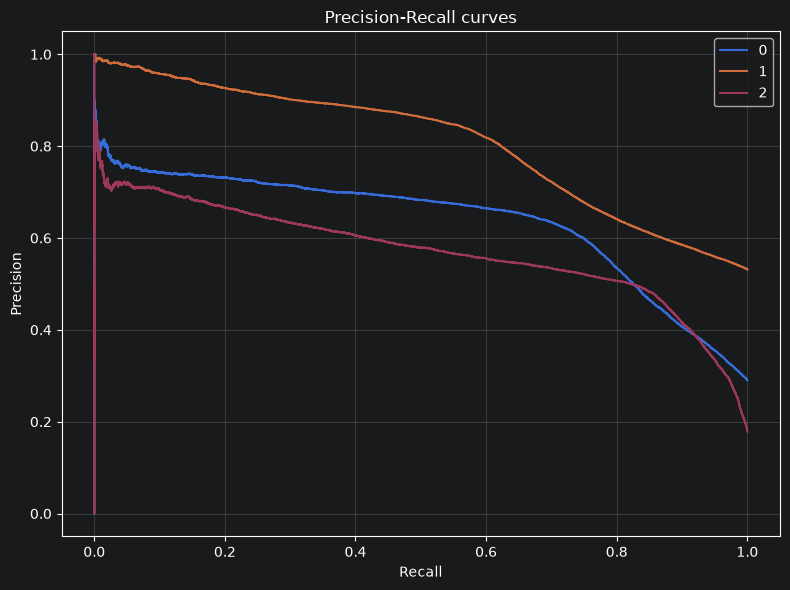

In [14]:
plt.figure(figsize=(8, 6))
for class_name, curve in pr_curves.items():
    plt.plot(curve["recall"], curve["precision"], label=class_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
pr_curve_points = pd.Series({class_name: len(curve) for class_name, curve in pr_curves.items()}, name="points")
display(pr_curve_points.to_frame())

,points
0,80001
1,80001
2,80001
